# 02 - Feature Extraction

In [7]:
import os
import sys
from pathlib import Path

# locate src/ by searching upward from cwd (Jupyter does not define __file__)
_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import cv2
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

from config import SEED, FIGURES_DIR, PROCESSED_DIR, HSV_BINS, IMAGE_SIZE
from features import hsv_histogram

## 1 - Load balanced subset

In [8]:
subset_path = PROCESSED_DIR / "balanced_subset.csv"
df = pd.read_csv(subset_path)

print(f"Rows loaded : {len(df)}")
print(f"Columns     : {list(df.columns)}")
print(f"Class counts:\n{df['label'].value_counts().to_string()}")

Rows loaded : 2226
Columns     : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'label', 'image_path']
Class counts:
label
1    1113
0    1113


## 2 - Feature extraction

HAM10000 images have varying resolutions  
Resizing to a fixed image size  
L1 normalisation

In [9]:
feat_dim = sum(HSV_BINS)  # 96

records = []          # (image_id, label, feature_vector)
skipped = []          # image_ids that could not be loaded

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting HSV features"):
    img_path = row.get("image_path")

    if pd.isna(img_path) or not Path(str(img_path)).exists():
        skipped.append(row["image_id"])
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        skipped.append(row["image_id"])
        continue

    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    feat = hsv_histogram(img_resized, bins=HSV_BINS)
    records.append((row["image_id"], int(row["label"]), feat))

print(f"\nProcessed : {len(records)}")
print(f"Skipped   : {len(skipped)}")
if skipped:
    print("Skipped image_ids:", skipped)

Extracting HSV features:   0%|          | 0/2226 [00:00<?, ?it/s]


Processed : 2226
Skipped   : 0


## 3 - Assemble and save feature matrix

In [10]:
image_ids = np.array([r[0] for r in records])
y         = np.array([r[1] for r in records], dtype=np.int32)
X         = np.stack([r[2] for r in records])  # shape (N, 96)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "features_hsv.npz"
np.savez_compressed(out_path, X=X, y=y, image_ids=image_ids)
print(f"\nSaved to: {out_path}")

X shape : (2226, 96)
y shape : (2226,)

Saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\data\processed\features_hsv.npz


## 4 - Sanity check

We verify that:
- Each feature vector sums to 1 (L1 normalisation).
- The per-class mean histograms look different.

In [11]:
print("=== Normalisation check ===")
row_sums = X.sum(axis=1)
print(f"  Row sum - mean: {row_sums.mean():.6f}, std: {row_sums.std():.2e}, "
      f"min: {row_sums.min():.6f}, max: {row_sums.max():.6f}")

print("\n=== Per-class mean histogram L1 norm ===")
for lbl, name in [(0, "Nevus"), (1, "Melanoma")]:
    mean_hist = X[y == lbl].mean(axis=0)
    print(f"  {name:10s}: L1 norm = {mean_hist.sum():.6f}")

print("\n=== Per-channel mean values (H / S / V) ===")
h_bins, s_bins, v_bins = HSV_BINS
for lbl, name in [(0, "Nevus"), (1, "Melanoma")]:
    m = X[y == lbl].mean(axis=0)
    print(f"  {name:10s}  H-mean={m[:h_bins].mean():.4f}  "
          f"S-mean={m[h_bins:h_bins+s_bins].mean():.4f}  "
          f"V-mean={m[h_bins+s_bins:].mean():.4f}")

=== Normalisation check ===
  Row sum - mean: 1.000000, std: 2.45e-08, min: 1.000000, max: 1.000000

=== Per-class mean histogram L1 norm ===
  Nevus     : L1 norm = 1.000000
  Melanoma  : L1 norm = 1.000000

=== Per-channel mean values (H / S / V) ===
  Nevus       H-mean=0.0104  S-mean=0.0104  V-mean=0.0104
  Melanoma    H-mean=0.0104  S-mean=0.0104  V-mean=0.0104


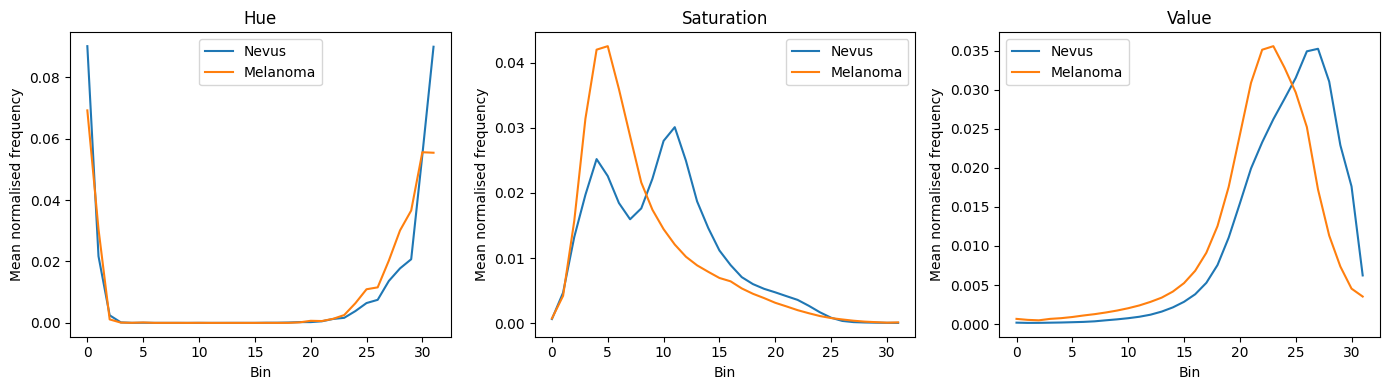

In [12]:
import matplotlib.pyplot as plt

h_bins, s_bins, v_bins = HSV_BINS

mean_nevus = X[y == 0].mean(axis=0)
mean_mel = X[y == 1].mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

slices = [
    (0, h_bins, "Hue", "Bin"),
    (h_bins, h_bins + s_bins, "Saturation", "Bin"),
    (h_bins + s_bins, h_bins + s_bins + v_bins, "Value", "Bin"),
]

for ax, (a, b, title, xlabel) in zip(axes, slices):
    ax.plot(mean_nevus[a:b], label="Nevus")
    ax.plot(mean_mel[a:b], label="Melanoma")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean normalised frequency")
    ax.legend()

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIGURES_DIR / "mean_hsv_histograms_by_class.png"

plt.savefig(out_path, dpi=200)
plt.show()